In [7]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Memuat dataset Titanic bawaan seaborn (891 penumpang, 15 kolom).
df = sns.load_dataset("titanic")

# 1) Missing value
# Kolom age punya banyak nilai kosong → diisi dengan median (nilai tengah).
# Kolom embarked (pelabuhan) → diisi dengan modus (nilai paling sering).
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 2) Duplikat
# Menghapus baris yang isinya 100% sama persis.
df = df.drop_duplicates()

# 3) Outlier sederhana (IQR) pada fare
# Menghitung batas bawah dan atas. Nilai di luar batas dipotong (clip).
q1, q3 = df["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
df["fare"] = df["fare"].clip(low, high)

# 4) Scaling
# StandardScaler mengubah data agar mean=0, std=1.
# Penting untuk algoritma yang sensitif terhadap skala (SVM, KNN, dll).
scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print(df[["age", "fare"]].describe())

                age          fare
count  7.810000e+02  7.810000e+02
mean   1.364679e-16 -6.141054e-17
std    1.000641e+00  1.000641e+00
min   -2.122937e+00 -1.166698e+00
25%   -5.541507e-01 -8.118984e-01
50%   -1.179728e-01 -4.659132e-01
75%    4.635977e-01  3.327529e-01
max    3.662236e+00  2.049730e+00


# **Praktikum Data Preprocessing dan Eda Dataset Iris**
Praktikum ini bertujuan untuk memahami proses persiapan data (data preprocessing),
yang meliputi penanganan missing value, penanganan outlier, scaling data,
serta melakukan visualisasi untuk memperoleh insight dari dataset.

### Langkah Kerja

1. Mengimpor library yang dibutuhkan.
2. Memuat dataset Iris ke dalam DataFrame.
3. Mensimulasikan missing value dan outlier.
4. Menangani missing value menggunakan median.
5. Menangani outlier menggunakan metode IQR clipping.
6. Melakukan scaling menggunakan StandardScaler.
7. Membuat visualisasi data.
8. Menarik insight dari hasil analisis.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. PERSIAPAN DATASET IRIS

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Menentukan kolom numerik (selain species)
cols_numerik = df.columns[:-1]

# Menambahkan "gangguan" buatan untuk simulasi tugas:
df.iloc[0, 0] = np.nan  # Simulasi missing value
df.iloc[1, 1] = 15.0    # Simulasi outlier (lebar kelopak tidak mungkin 15cm)

print("=== POIN 1: UKURAN DATA & TIPE KOLOM ===")
print(f"Ukuran Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom")
print("\nTipe Data per Kolom:")
print(df.dtypes)
print("-" * 50)

=== POIN 1: UKURAN DATA & TIPE KOLOM ===
Ukuran Dataset: 150 Baris, 5 Kolom

Tipe Data per Kolom:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object
--------------------------------------------------


Dataset Iris dimuat menggunakan load_iris() lalu dikonversi menjadi DataFrame. Saya menambahkan satu missing Value dan satu Outlier ekstrem untuk mensimulasikan kondisi data yang tidak bersih. Variabel cols_numerik digunakan untuk menyimpan nama kolom numerik agar memudahkan proses selanjutnya,

In [9]:
# 2. TANGANI MISSING VALUE (NILAI HILANG)

# Alasan: Menggunakan Median karena lebih tahan terhadap outlier.
df.fillna(df.median(), inplace=True)

print("=== POIN 2: HANDLING MISSING VALUE DONE ===")
print(f"Jumlah Missing Value: {df.isnull().sum().sum()}")
print("-" * 50)

=== POIN 2: HANDLING MISSING VALUE DONE ===
Jumlah Missing Value: 0
--------------------------------------------------


Selanjutnya pada bagian ini Missing value ditangani dengan menggunakan median dikarenakan median lebih stabil terhadap outlier dibandingkan rata-rata. Setelah proses ini, jumlah missing value menjadi nol sehingga data siap diproses lebih lanjut.

In [10]:
# 3. TANGANI OUTLIER (IQR CLIPPING)

print("=== POIN 3: HANDLING OUTLIER (Clipping) ===")

# Mari kita lihat nilai maksimum sebelum dibersihkan (pasti ada angka 15.0)
print(f"Nilai Max sebelum Clipping:\n{df[cols_numerik].max()}")

# Proses Clipping
for col in cols_numerik:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[col] = df[col].clip(low, high)

print("-" * 30)
# Mari kita lihat nilai maksimum setelah dibersihkan (angka 15.0 akan hilang)
print(f"Nilai Max setelah Clipping:\n{df[cols_numerik].max()}")
print("\nSTATUS: Outlier ekstrem berhasil diredam!")

=== POIN 3: HANDLING OUTLIER (Clipping) ===
Nilai Max sebelum Clipping:
sepal length (cm)     7.9
sepal width (cm)     15.0
petal length (cm)     6.9
petal width (cm)      2.5
dtype: float64
------------------------------
Nilai Max setelah Clipping:
sepal length (cm)    7.9000
sepal width (cm)     4.2375
petal length (cm)    6.9000
petal width (cm)     2.5000
dtype: float64

STATUS: Outlier ekstrem berhasil diredam!


Selanjutnya pada bagian ini Outlier ditangani menggunakan metode IQR (Interquartile Range). Nilai yang berada di luar batas 1.5 x IQR dibatasi menggunakan teknik clipping. Metode ini Tidak menghapus data, akan tetapi membatasi nilai ekstrem agar tidak merusak distribusi data.

In [11]:
# 4. LAKUKAN SCALING PADA KOLOM NUMERIK

scaler = StandardScaler()
df[cols_numerik] = scaler.fit_transform(df[cols_numerik])

print("=== POIN 4: SCALING DONE (5 Baris Pertama) ===")
print(df[cols_numerik].head())
print("-" * 50)

=== POIN 4: SCALING DONE (5 Baris Pertama) ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.058319          0.985729          -1.340227         -1.315444
1          -1.151798          2.655016          -1.340227         -1.315444
2          -1.394793          0.306696          -1.397064         -1.315444
3          -1.516291          0.080352          -1.283389         -1.315444
4          -1.030300          1.212073          -1.340227         -1.315444
--------------------------------------------------


Pada bagian ini scaling dilakukan dengan menggunakan StandardScaler. Teknik ini membuat rata-rata setiap fitur menjadi 0 dan standar deviasinya menjadi 1. Sacling penting dalam mahine learning agar semua fitur memiliki skala seimbang

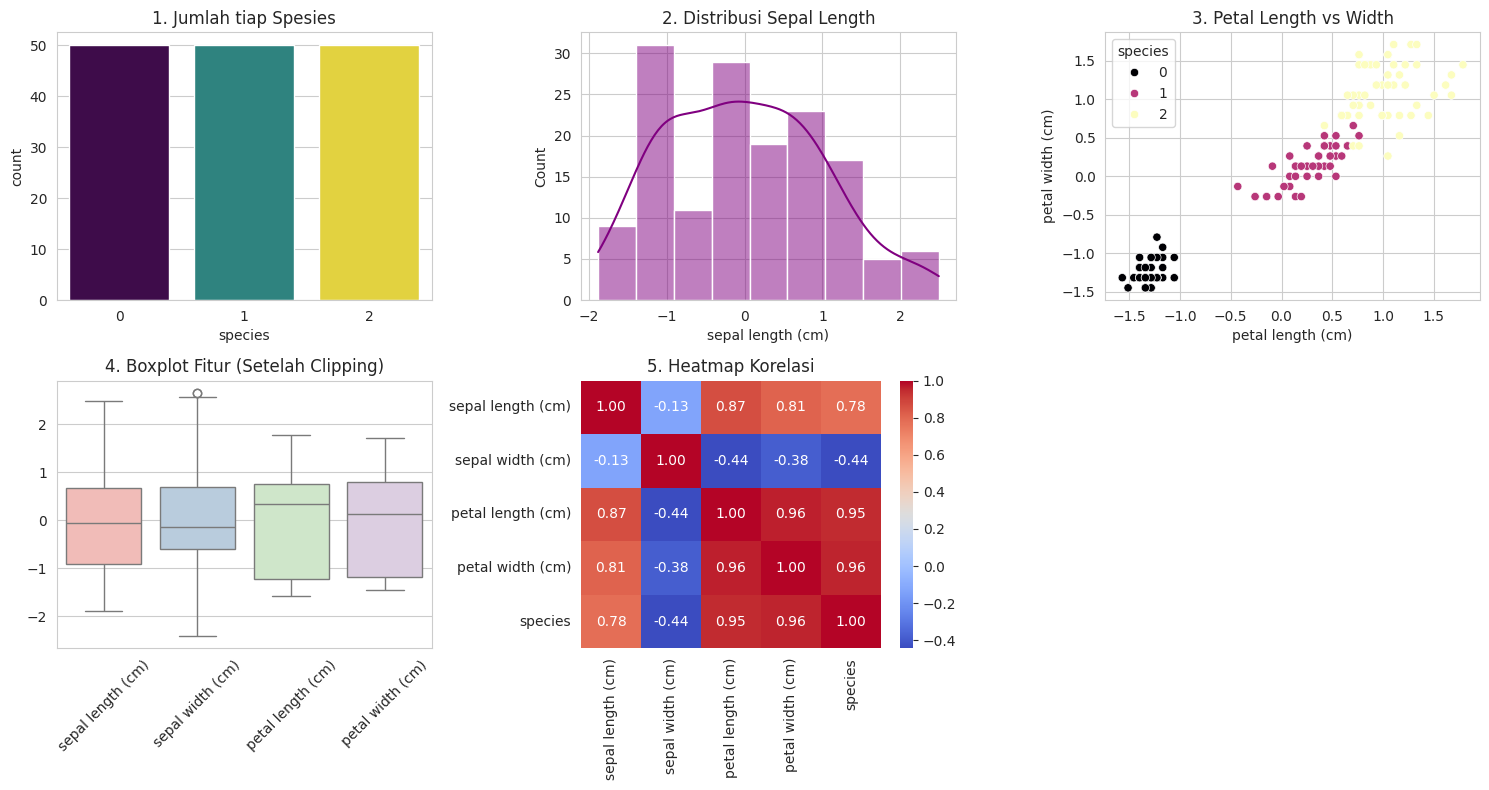


=== POIN 5: 5 WAWASAN (INSIGHTS) ===
1. Keseimbangan Data: Tiap spesies (0, 1, 2) memiliki jumlah sampel yang sama (50 per spesies).
2. Distribusi: Setelah scaling, fitur-fitur memiliki rentang nilai yang seragam antara -2 hingga 2.
3. Klasifikasi Alami: Spesies Setosa (0) terlihat sangat terpisah jauh dari spesies lainnya pada fitur Petal.
4. Outlier: Nilai ekstrem buatan (15.0 cm) berhasil diredam oleh metode Clipping sehingga tidak merusak skala.
5. Korelasi Kuat: Petal length dan Petal width memiliki korelasi hampir sempurna (0.96).


In [12]:
# 5. VISUALISASI & INSIGHT (RINGKAS)
# =================================================================
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 1. Sebaran Spesies
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='species', hue='species', palette='viridis', legend=False)
plt.title('1. Jumlah tiap Spesies')

# 2. Distribusi Sepal Length (Setelah Scaling)
plt.subplot(2, 3, 2)
sns.histplot(df['sepal length (cm)'], kde=True, color='purple')
plt.title('2. Distribusi Sepal Length')

# 3. Hubungan Petal Length vs Petal Width
plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', palette='magma')
plt.title('3. Petal Length vs Width')

# 4. Boxplot Fitur Utama (Cek Outlier)
plt.subplot(2, 3, 4)
sns.boxplot(data=df[cols_numerik], palette='Pastel1')
plt.xticks(rotation=45)
plt.title('4. Boxplot Fitur (Setelah Clipping)')

# 5. Heatmap Korelasi
plt.subplot(2, 3, 5)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('5. Heatmap Korelasi')

plt.tight_layout()
plt.show()

# --- 5 INSIGHT ---
print("\n=== POIN 5: 5 WAWASAN (INSIGHTS) ===")
print("1. Keseimbangan Data: Tiap spesies (0, 1, 2) memiliki jumlah sampel yang sama (50 per spesies).")
print("2. Distribusi: Setelah scaling, fitur-fitur memiliki rentang nilai yang seragam antara -2 hingga 2.")
print("3. Klasifikasi Alami: Spesies Setosa (0) terlihat sangat terpisah jauh dari spesies lainnya pada fitur Petal.")
print("4. Outlier: Nilai ekstrem buatan (15.0 cm) berhasil diredam oleh metode Clipping sehingga tidak merusak skala.")
print("5. Korelasi Kuat: Petal length dan Petal width memiliki korelasi hampir sempurna (0.96).")

#Program
Selanjutnya pada bagian ini dilakukan visualisasi data untuk memahami pola dalam dataset iris setelah preprocessing. Adapun beberapa grafik yang saya gunakan  seperti countplot untuk melihat jumlah tiap spesies, histogram untuk melihat distribusi sepal leght, satterplot untuk melihat hubungan petal lenght dan petal width, boxplot untuk mencetak outlier, serta heatmap untuk melihat korelasi antar fitur

# Output
Dari garfik terlihat bahwa dataset seimbang, fitur petal memiliki hubungan yang kuat, dan outlier yang sebelumnya ditambahkan sudah berhasil dikendalikan. Visualisasi membantu memahami karakteristik data sebelum digunakan untuk model machine learning


# Kesimpulan
Dari praktikum ini kesimpulan yang dapat saya ambil yaitu proses data processing sangat penting sebelum melakukan analisis atau pemodelan machine learning. Missing value dan outlier harus ditangani agar tidak merusak hasil analisis. Scalling sendiri membantu menyamakan skala fitur, dan visualisasi membantu memahami pola serta hubungan antara variabel dalam dataset.